In [2]:
# === EJERCICIO PRÁCTICO 1 — Riesgo Cardiovascular ===
## Examen Final - Aprendizaje Automático I - MIAA 2026-1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [4]:
# Cargar datos
data = pd.read_csv("/content/EXAMFINAL-riesgo_cardiovascular.data")
print(f"Shape: {data.shape}")
data.head()

Shape: (500, 5)


,Riesgo_Cardiovascular,Horas_Sueno,Tazas_Cafe,Horas_Ejercicio,Minutos_Redes
0,22.113604,7.583928,2,7.490802,26.000146
1,40.941898,6.640708,1,19.014286,13.705176
2,26.681755,7.590655,3,14.639879,47.409682
3,19.336421,8.108704,0,11.973170,55.144114
4,27.219817,7.820482,1,3.120373,42.974581


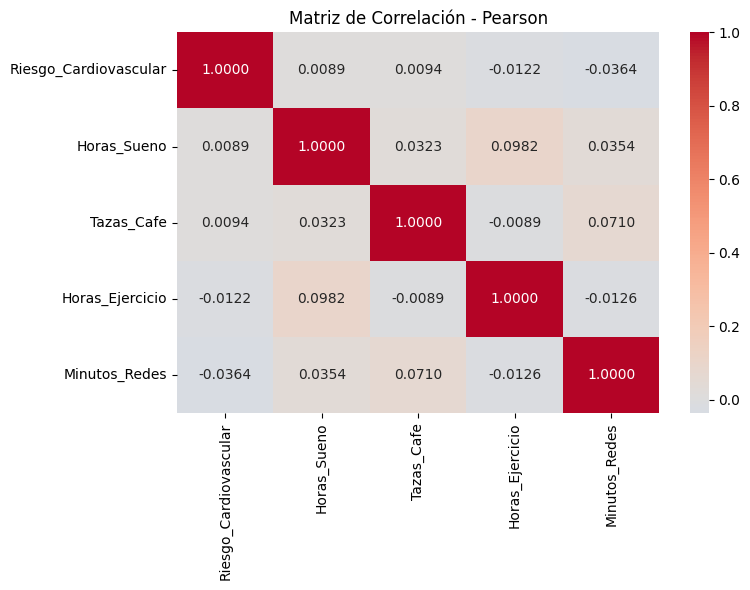


Correlaciones con Riesgo_Cardiovascular:
Minutos_Redes           -0.036439
Horas_Ejercicio         -0.012220
Horas_Sueno              0.008869
Tazas_Cafe               0.009398
Riesgo_Cardiovascular    1.000000
Name: Riesgo_Cardiovascular, dtype: float64


In [5]:
# === PREGUNTA 16: Matriz de correlación de Pearson ===
corr = data.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.4f')
plt.title('Matriz de Correlación - Pearson')
plt.tight_layout()
plt.show()

print("\nCorrelaciones con Riesgo_Cardiovascular:")
print(corr['Riesgo_Cardiovascular'].sort_values())

# CONCLUSIÓN: Todas las correlaciones lineales son < 0.1
# Pearson NO detecta relaciones no lineales → Respuesta: c

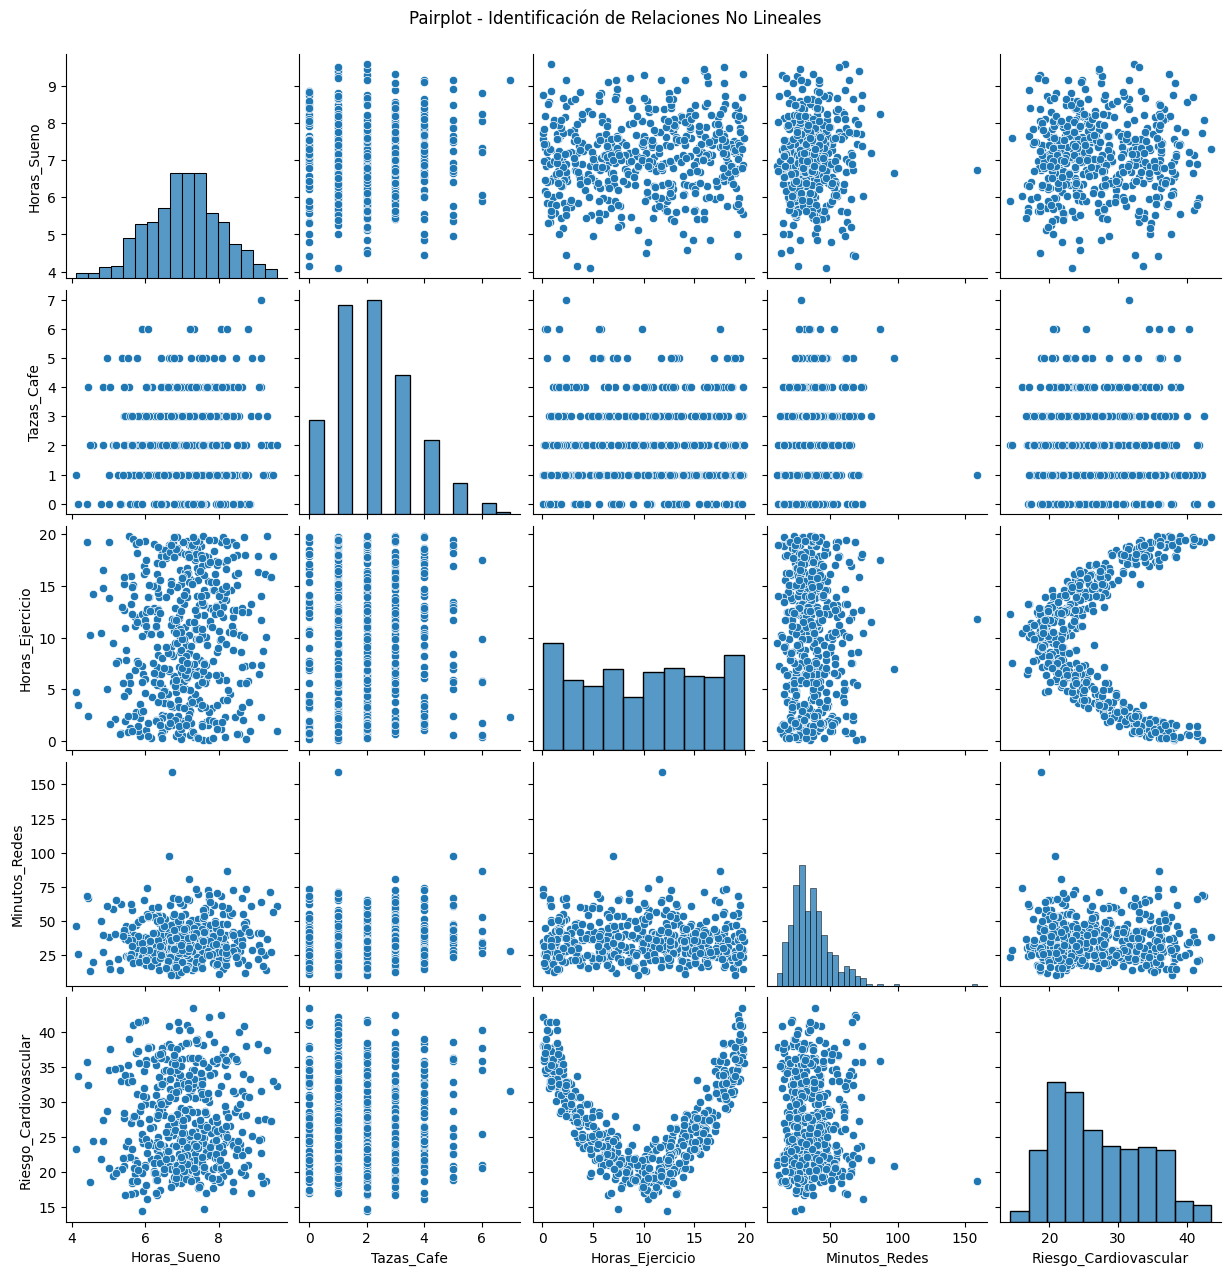

In [6]:
# === PREGUNTA 17 y 18: Pairplot para identificar patrones no lineales ===
sns.pairplot(data[['Horas_Sueno', 'Tazas_Cafe', 'Horas_Ejercicio', 'Minutos_Redes', 'Riesgo_Cardiovascular']])
plt.suptitle('Pairplot - Identificación de Relaciones No Lineales', y=1.02)
plt.show()

# CONCLUSIÓN: Se observa relación parabólica entre Horas_Ejercicio y Riesgo_Cardiovascular
# Respuesta P17: d (pairplot) | Respuesta P18: e (parabólica Ejercicio vs Riesgo)

In [7]:
# === PREGUNTA 19: Regresión Lineal vs Polinomial (grado 2) ===
X = data[['Horas_Ejercicio']]
y = data['Riesgo_Cardiovascular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Modelo 1: Regresión lineal simple ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)

# --- Modelo 2: Regresión polinomial grado 2 ---
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_poly_train, y_train)
y_pred_poly = lr_poly.predict(X_poly_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print(f"MSE Lineal:              {mse_lr:.2f}")
print(f"MSE Polinomial (grado 2): {mse_poly:.2f}")
print(f"Ratio MSE_lin / MSE_poly: {mse_lr/mse_poly:.1f}x")

# CONCLUSIÓN: Polinomial es 6.5x mejor → Respuesta P19: a | Respuesta P20: d

MSE Lineal:              42.64
MSE Polinomial (grado 2): 6.52
Ratio MSE_lin / MSE_poly: 6.5x


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


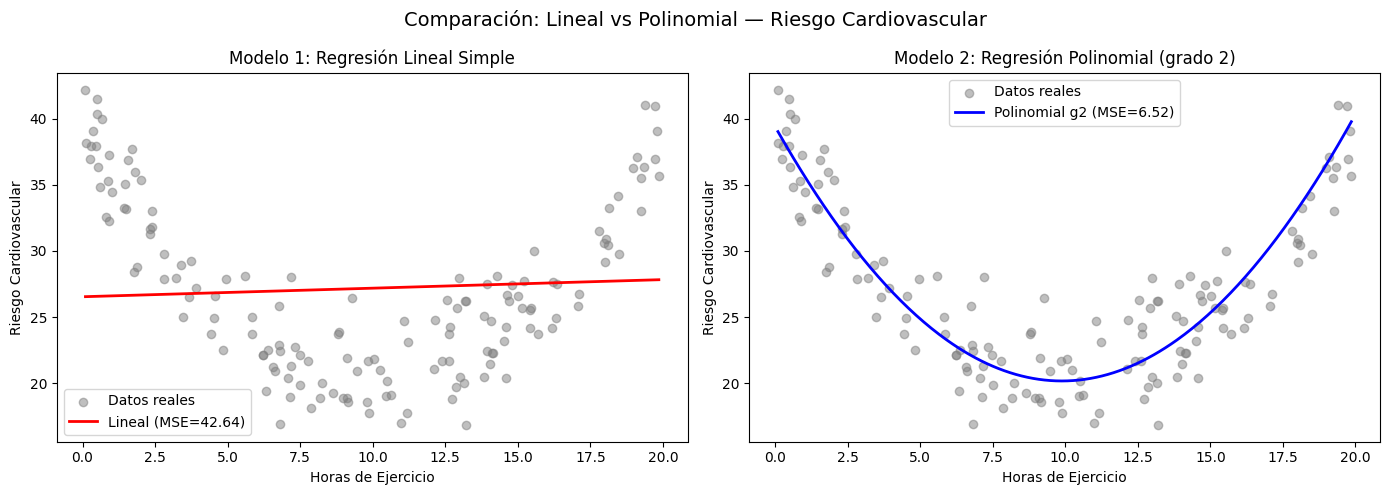

In [8]:
# === VISUALIZACIÓN: Comparación de ambos modelos ===
X_range = np.linspace(X['Horas_Ejercicio'].min(), X['Horas_Ejercicio'].max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modelo Lineal
axes[0].scatter(X_test, y_test, alpha=0.5, label='Datos reales', color='gray')
axes[0].plot(X_range, lr.predict(X_range), color='red', linewidth=2, label=f'Lineal (MSE={mse_lr:.2f})')
axes[0].set_title('Modelo 1: Regresión Lineal Simple')
axes[0].set_xlabel('Horas de Ejercicio')
axes[0].set_ylabel('Riesgo Cardiovascular')
axes[0].legend()

# Modelo Polinomial
axes[1].scatter(X_test, y_test, alpha=0.5, label='Datos reales', color='gray')
X_range_poly = poly.transform(X_range)
axes[1].plot(X_range, lr_poly.predict(X_range_poly), color='blue', linewidth=2, label=f'Polinomial g2 (MSE={mse_poly:.2f})')
axes[1].set_title('Modelo 2: Regresión Polinomial (grado 2)')
axes[1].set_xlabel('Horas de Ejercicio')
axes[1].set_ylabel('Riesgo Cardiovascular')
axes[1].legend()

plt.suptitle('Comparación: Lineal vs Polinomial — Riesgo Cardiovascular', fontsize=14)
plt.tight_layout()
plt.show()